# Code for simple vs Polynomial regression 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [5]:
x= 6*np.random.rand(200,1)-3
y=0.8*x**2 + 0.9*x + 2 + np.random.randn(200,1)
#y=0.8x^2 +0.9x +2

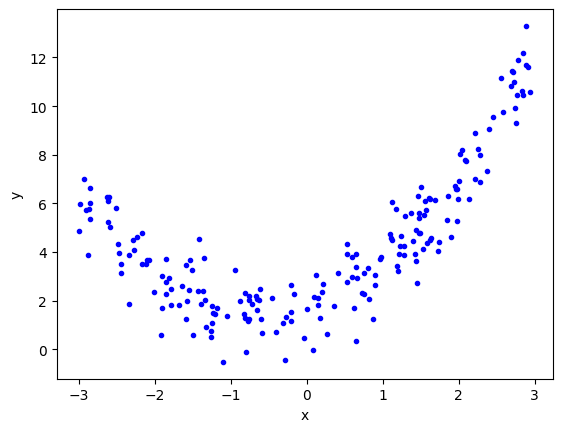

In [6]:
# now see the data 
plt.plot(x,y,'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
# applying linear regression model
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.11473933262751923

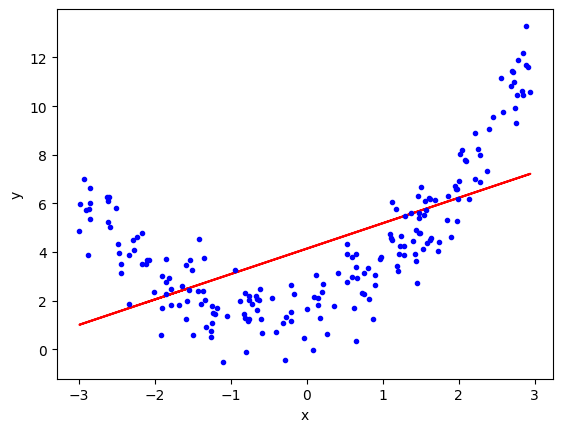

In [10]:
plt.plot(x_train,lr.predict(x_train),color ='r')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# APPLYING POLYNOMIAL LINEAR REGRESSION

In [11]:
poly=PolynomialFeatures(degree=2)
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.fit_transform(x_test)

In [12]:
print(x_train[0])
print(x_train_trans[0])

[-2.12027037]
[ 1.         -2.12027037  4.49554644]


# Linear Regression

In [13]:
lr=LinearRegression()
lr.fit(x_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred=lr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.8991672594226351

In [15]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.98346085 0.81692816]]
[1.7574646]


# PLOT THE POINTS FOR THE BEST FIT

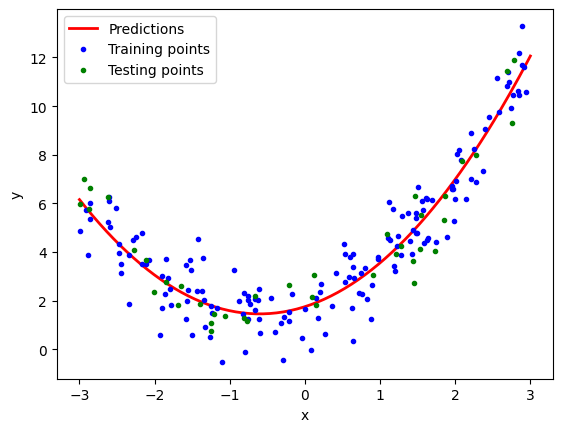

In [16]:
# PLOT THE POINTS FOR THE BEST FIT

# 1. Create 200 evenly spaced points spanning from -3 to 3
x_new = np.linspace(-3, 3, 200).reshape(-1, 1)

# 2. Transform these new points into polynomial features
x_new_trans = poly.transform(x_new)

# 3. Predict the y-values for these new points using your trained model
y_new = lr.predict(x_new_trans)

# 4. Plot the results safely
plt.plot(x_new, y_new, 'r-', linewidth=2, label='Predictions')
plt.plot(x_train, y_train, 'b.', label='Training points')
plt.plot(x_test, y_test, 'g.', label='Testing points')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [17]:
x.shape

(200, 1)

In [18]:
x.max()

np.float64(2.943192204728626)

# SAME POLYNOMIAL REGRESSION FOR 3D

In [19]:
x=7*np.random.rand(100,1)-2.8
y=7*np.random.rand(100,1)-2.8
z= x**2 + y**2 +0.2*x+0.2*y+0.1*x*y+2+np.random.randn(100,1)

In [20]:
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

# now lets try multiple linear regerssion first 

In [21]:
lr =LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
x_input=np.linspace(x.min(),x.max(),10)
y_input=np.linspace(y.min(),y.max(),10)
xGrid,yGrid=np.meshgrid(x_input,y_input)
final=np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final=lr.predict(final).reshape(10,10)

In [23]:
import plotly.graph_objects as go
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input,z=z_final))
fig.show()

# POLYNOMIAL FEATURE TRANSFORMATION

In [30]:
x_multi=np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [31]:
poly = PolynomialFeatures(degree=3)
x_multi_trans= poly.fit_transform(x_multi)

print("Input", poly.n_features_in_)
print("Output", poly.n_output_features_)
print('power\n', poly.powers_)


Input 2
Output 10
power
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [26]:
x_multi_trans.shape

(100, 10)

In [27]:
lr=LinearRegression()
lr.fit(x_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
x_test_multi=poly.transform(final)
z_final=lr.predict(x_multi_trans).reshape(10,10)
fig=px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.update_layout(scene=dict(zaxis=dict(range=[0,35])))
fig.show()

In [29]:
r2_score(z,lr.predict(x_multi_trans))

0.9851825425063279